In [1]:
!pip install nbformat

In [2]:
!pip install graphviz

In [3]:
!pip install dtreeviz

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_context('notebook')
sns.set_style('white')

import dtreeviz

In [5]:
training = pd.read_csv(r"C:\Users\91636\Desktop\major_project\New folder\cyber\UNSW_NB15_training-set.csv")
testing = pd.read_csv(r"C:\Users\91636\Desktop\major_project\New folder\cyber\UNSW_NB15_testing-set.csv")
print("training ",training.shape)
print("testing ",testing.shape)

training  (175341, 45)
testing  (82332, 45)


In [6]:
all(training.columns == testing.columns)

True

In [7]:
df = pd.concat([training,testing]).drop('id',axis=1)
df = df.reset_index(drop=True)

df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,Normal,0


In [8]:
df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

In [10]:
df.attack_cat.unique()

array(['Normal', 'Backdoor', 'Analysis', 'Fuzzers', 'Shellcode',
       'Reconnaissance', 'Exploits', 'DoS', 'Worms', 'Generic'],
      dtype=object)

## Categorical data

In [11]:
for col in ['proto', 'service', 'state']:
    df[col] = df[col].astype('category').cat.codes
    
df['attack_cat'] = df['attack_cat'].astype('category')

In [12]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,113,0,4,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,113,0,4,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,113,0,4,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,113,3,4,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,113,0,4,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,Normal,0


attack_cat
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Normal                0
Name: count, dtype: int64


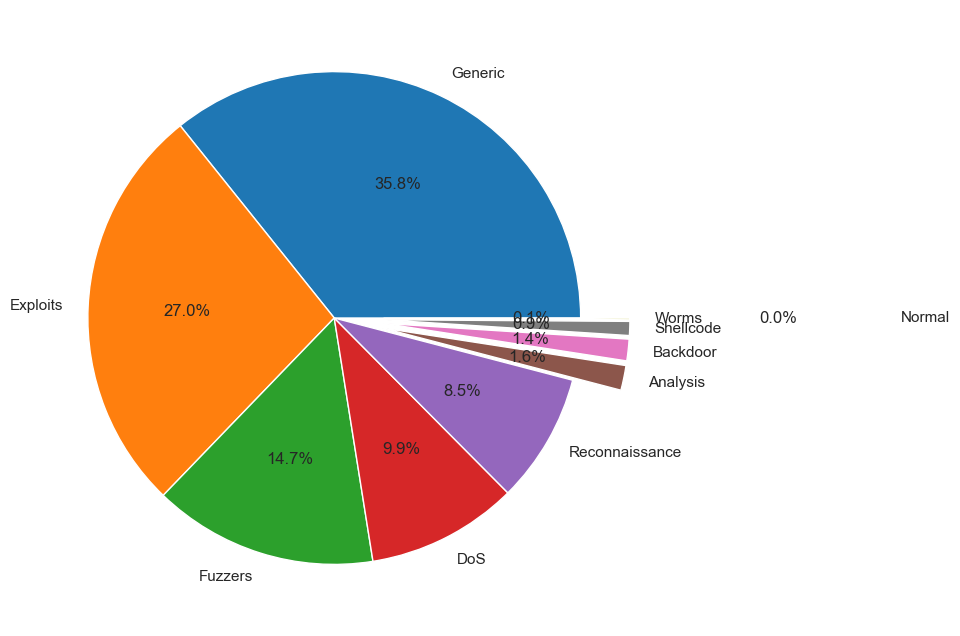

In [13]:
validAttacks = df[df['label']==1]['attack_cat'].value_counts()
print(validAttacks)

plt.figure(figsize = (15,8))
plt.pie(validAttacks,labels = validAttacks.index, autopct = '%1.1f%%',explode = [0,0,0,0,0,0.2,0.2,0.2,0.2,1.2])
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['attack_cat', 'label'])
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

feature_names = list(X.columns)

print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (180371, 42)
y_train shape:  (180371,)
X_test shape:  (77302, 42)
y_test shape:  (77302,)


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

dt = DecisionTreeClassifier()

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best recall score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best recall score: 1.0


In [16]:
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

clf=grid_search.best_estimator_
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

recall = recall_score(y_test, y_pred)
print("Recall: ", recall)

Recall:  1.0


## Visualizing the rules

In [17]:
pip install graphviz dtreeviz


Note: you may need to restart the kernel to use updated packages.


:::::::> The RULES FOR HIGH RECALL RATE <::::::: 
 |--- sttl <= 61.00
|   |--- sinpkt <= 0.00
|   |   |--- class: 1
|   |--- sinpkt >  0.00
|   |   |--- class: 0
|--- sttl >  61.00
|   |--- synack <= 0.04
|   |   |--- class: 1
|   |--- synack >  0.04
|   |   |--- class: 1



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


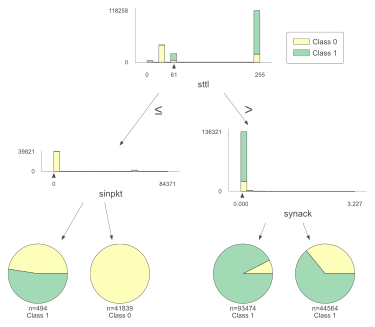

In [18]:
from sklearn.tree import export_text
import dtreeviz

print(":::::::> The RULES FOR HIGH RECALL RATE <::::::: \n" ,export_text(clf,feature_names=feature_names))

viz_model = dtreeviz.model(clf,
                           X_train=X_train, y_train=y_train, 
                           feature_names=feature_names)  
viz_model.view()

* From the decision tree, we visualized the rule of tree as sttl<=61 and sttl>61

In [19]:
X_test = X_test.reset_index(drop=True)

rules= "(sttl <= 61.00 & sinpkt<= 0.00) | (sttl >  61.00 )"

ind = X_test.query(rules).index

X_test_2 = X_test.loc[ind,:]
y_test_2 = y_test[ind]

print(X_test.shape)
print(X_test_2.shape)
print("filtered data" , (1- np.round(X_test_2.shape[0] / X_test.shape[0],2))*100, "%")

(77302, 42)
(59265, 42)
filtered data 23.0 %


* The rule based system filtered 23% of network traffic for further analysis, demonstrating its efficacy in detecting non-threatening network activity. Now, we will detect cyber attacks by applying the trained model to the filtered test data.

In [20]:
from sklearn.metrics import accuracy_score, precision_score

In [21]:
def model_evaluation(model):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test_2)
    
    accuracy = accuracy_score(y_test_2, y_pred)
    recall = recall_score(y_test_2, y_pred)
    precision = precision_score(y_test_2, y_pred)
    print("Recall: ", recall)
    print("Precision: ", precision)
    print("Accuracy: ", accuracy)
    
    cross = pd.crosstab(pd.Series(y_test_2, name='Actual'), pd.Series(y_pred, name='Predicted'))
    plt.figure(figsize=(5, 5))
    sns.heatmap(cross, annot=True,fmt='d', cmap="YlGnBu")
    plt.show()
    
    return {'Recall' : recall}

In [22]:
results = {}

## Random Forest Model

Recall:  0.9591163797463234
Precision:  0.9648744352639506
Accuracy:  0.9367754998734498


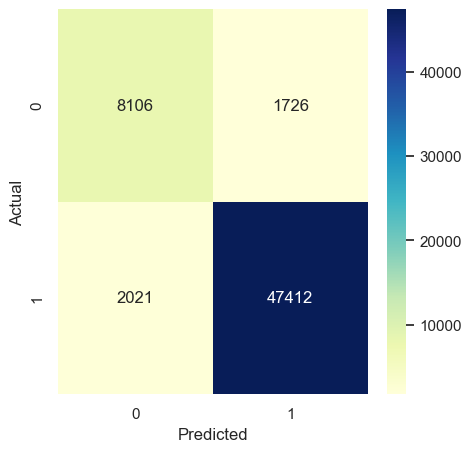

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Define and train the model
rf_model = RandomForestClassifier(random_state=11)
rf_model.fit(X_train, y_train)

# Save the evaluation result
results['Random Forest Model'] = model_evaluation(rf_model)


## Visualizing the rules present in the tree

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=11)


In [25]:
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.tree import export_text

feature_names = list(X_train.columns)
print(export_text(rf.estimators_[99], feature_names=feature_names))


|--- dpkts <= 0.50
|   |--- ct_srv_src <= 2.50
|   |   |--- sbytes <= 53.00
|   |   |   |--- sinpkt <= 30000.00
|   |   |   |   |--- sbytes <= 26.00
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- sbytes >  26.00
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- sinpkt >  30000.00
|   |   |   |   |--- class: 0.0
|   |   |--- sbytes >  53.00
|   |   |   |--- rate <= 0.10
|   |   |   |   |--- sbytes <= 76.00
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- sbytes >  76.00
|   |   |   |   |   |--- sttl <= 159.00
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- sttl >  159.00
|   |   |   |   |   |   |--- ct_src_dport_ltm <= 1.50
|   |   |   |   |   |   |   |--- sinpkt <= 7486.24
|   |   |   |   |   |   |   |   |--- ct_src_ltm <= 1.50
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- ct_src_ltm >  1.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- sinpkt >  7486.24
|   |   |   |

In [27]:
!pip install xgboost


Recall:  0.9526025124916554
Precision:  0.9644846796657381
Accuracy:  0.9312072892938497


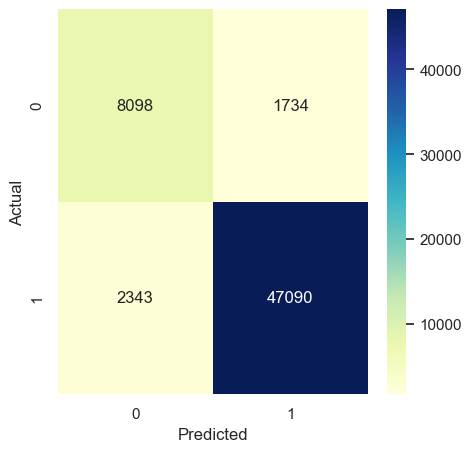

In [28]:
from xgboost import XGBClassifier

xgbc = XGBClassifier()

results['XGBoost Classifier'] = model_evaluation(xgbc)

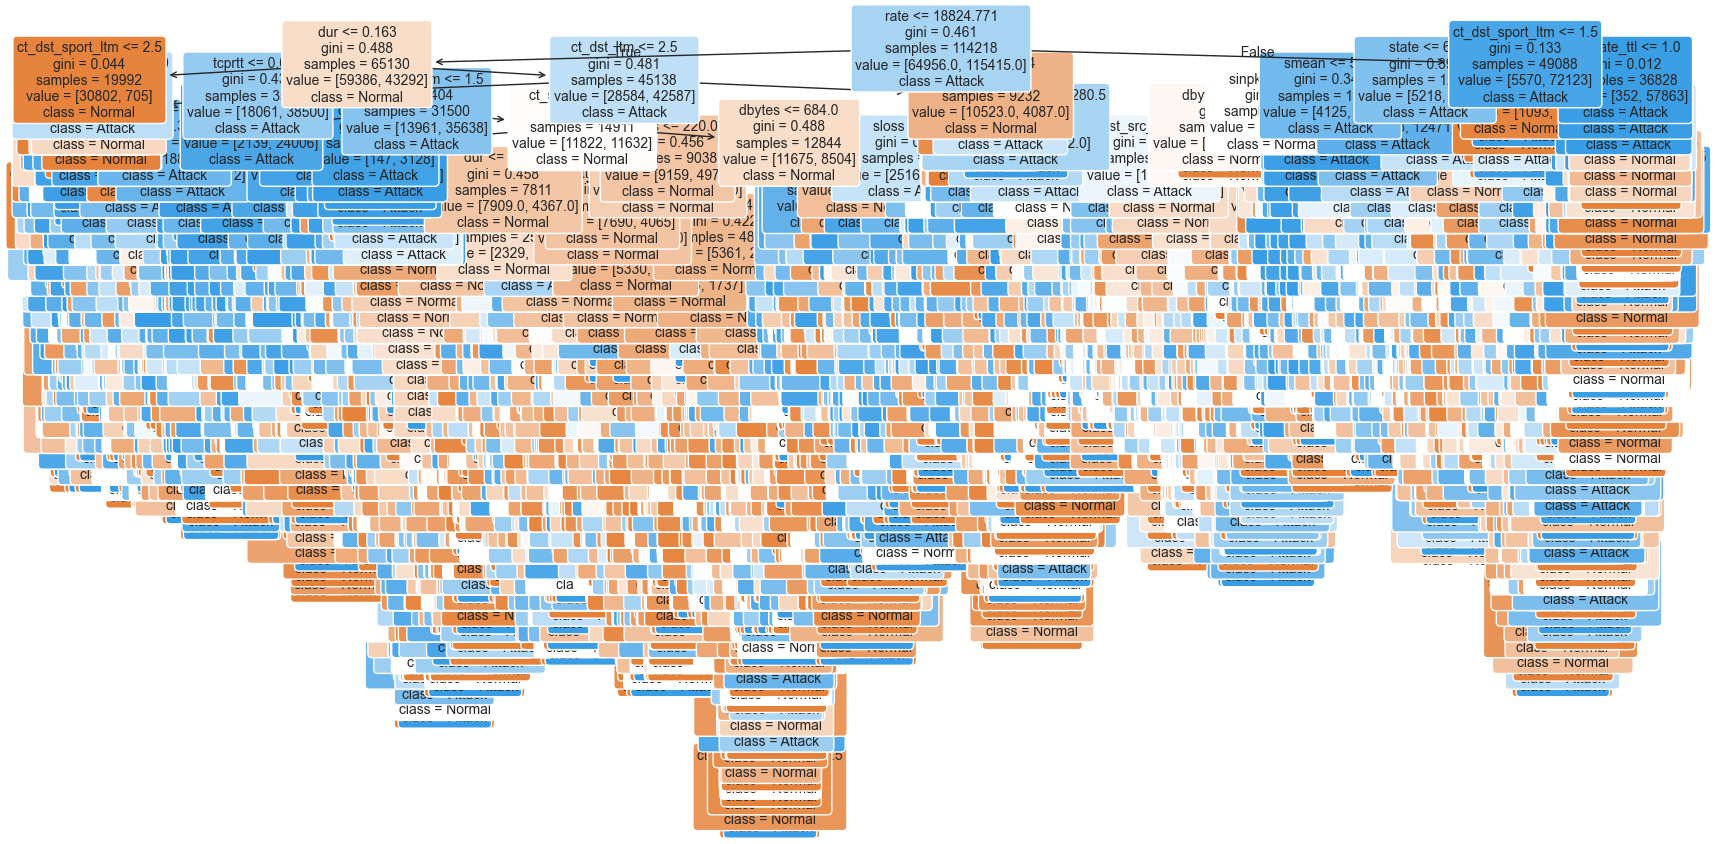

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming `rf` is your trained RandomForestClassifier and `X_train` is your training set
plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],                         # Visualize the first tree
    filled=True,
    feature_names=X_train.columns,
    class_names=['Normal', 'Attack'],
    rounded=True,
    fontsize=10
)
plt.show()


In [30]:
!pip install lightgbm


[LightGBM] [Info] Number of positive: 115240, number of negative: 65131
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6185
[LightGBM] [Info] Number of data points in the train set: 180371, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.638905 -> initscore=0.570616
[LightGBM] [Info] Start training from score 0.570616
Recall:  0.9489207614346692
Precision:  0.9644311032526008
Accuracy:  0.9282038302539442


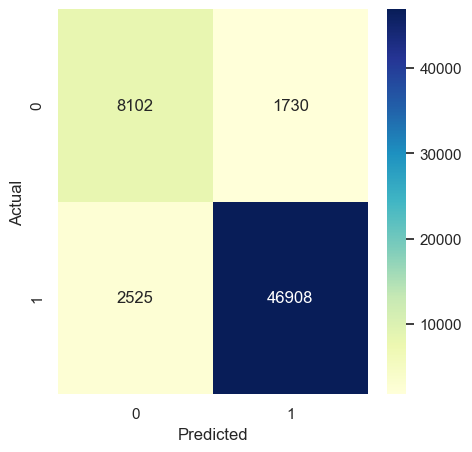

In [31]:
from lightgbm import LGBMClassifier

lgbc = LGBMClassifier()

results['Light GBM Classifier'] = model_evaluation(lgbc)

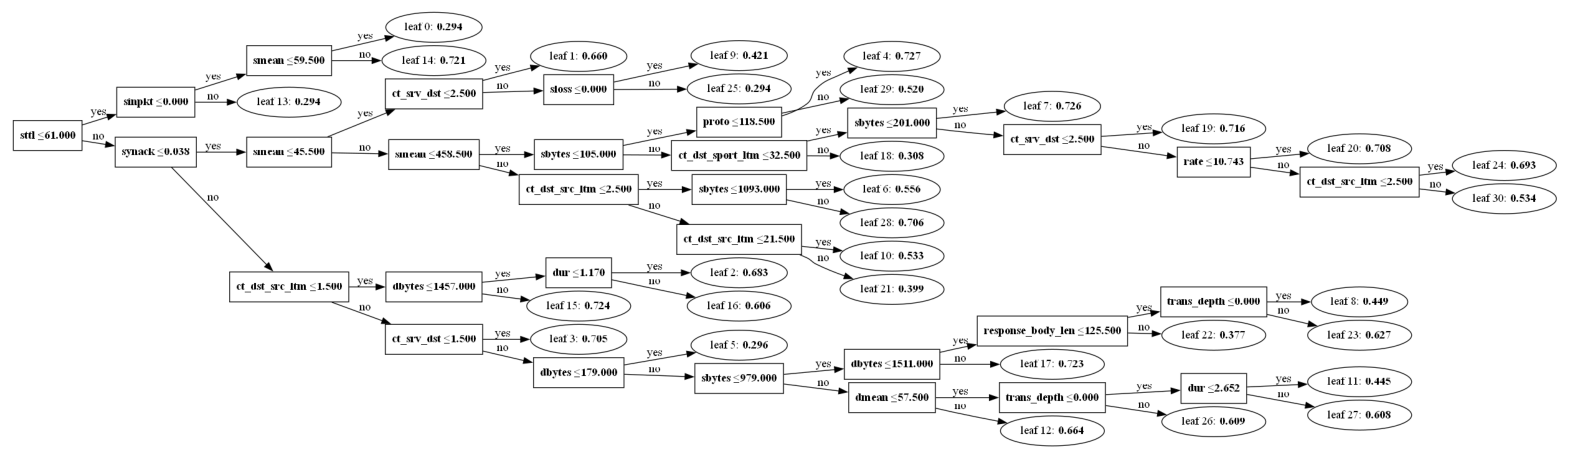

In [32]:
import lightgbm

lightgbm.plot_tree(lgbc,figsize = (20,12))
plt.show()

In [33]:
comparision = pd.DataFrame(results)
comparision

,Random Forest Model,XGBoost Classifier,Light GBM Classifier
Recall,0.959116,0.952603,0.948921


In [34]:
from scipy.stats import wilcoxon

z_statistic, p_value = wilcoxon([comparision.iloc[0][0], comparision.iloc[0][1], comparision.iloc[0][2]])

# Print the results
print('Z-statistic:', z_statistic)
print('p-value:', p_value)

# Interpret the results
if p_value < 0.05:
    print('The difference in the recall of the three models is statistically significant.')
else:
    print('The difference in the recall of the three models is not statistically significant.')


Z-statistic: 0.0
p-value: 0.25
The difference in the recall of the three models is not statistically significant.


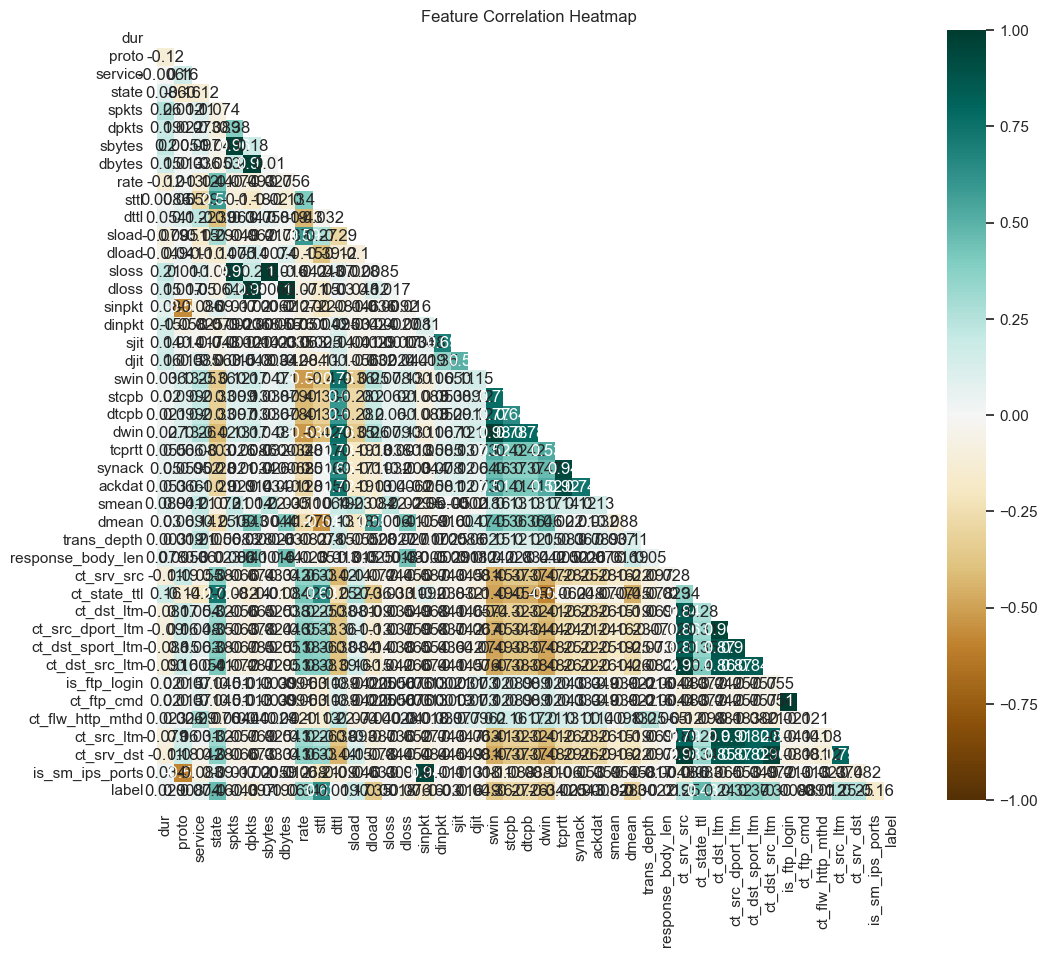

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Generate mask for upper triangle
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), vmin=-1, vmax=1, cmap='BrBG', mask=mask, annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [36]:
print(df['label'].unique())


[0 1]


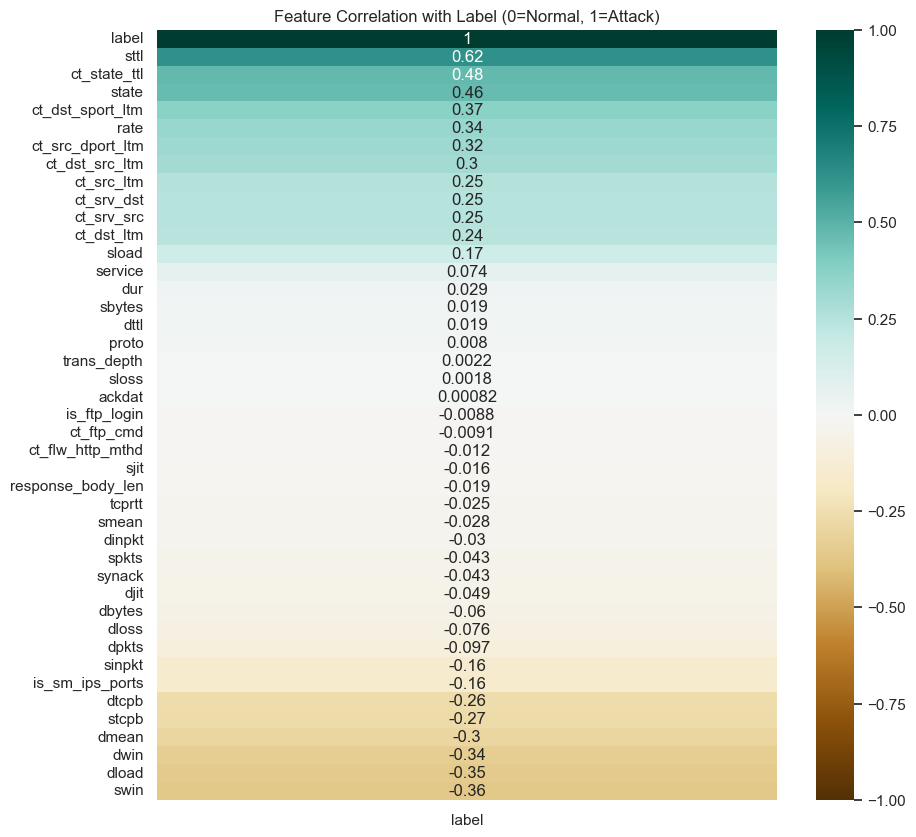

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure only numeric features are included
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation with the 'label' column
correlation_with_label = numeric_df.corr()['label'].sort_values(ascending=False)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_with_label.to_frame(), annot=True, cmap='BrBG', vmin=-1, vmax=1)
plt.title('Feature Correlation with Label (0=Normal, 1=Attack)')
plt.show()


In [38]:
feature_imp = pd.DataFrame({'Name':X.columns, 'Importance':rf.feature_importances_})

feature_imp = feature_imp.sort_values('Importance',ascending=False).reset_index(drop=True)

feature_imp[:10].style.background_gradient()

,Name,Importance
0,sttl,0.124812
1,ct_state_ttl,0.108264
2,rate,0.054368
3,sload,0.046936
4,sbytes,0.046677
5,dload,0.046650
6,ct_dst_src_ltm,0.041123
7,smean,0.036935
8,ct_srv_dst,0.036521
9,dttl,0.036385


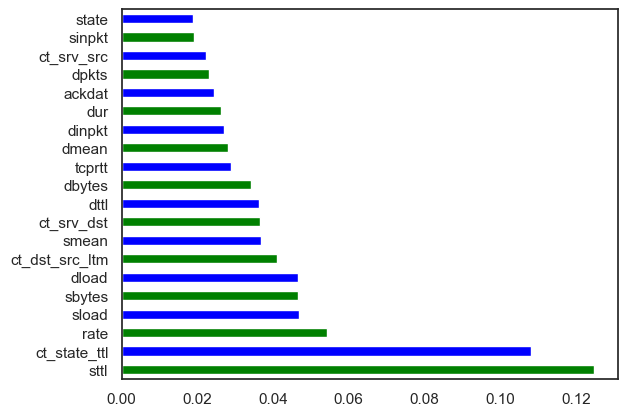

In [39]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh',color=['g','b']*5)
plt.show()

In [40]:
top10= feature_imp.Name[:10].tolist()
top10

['sttl',
 'ct_state_ttl',
 'rate',
 'sload',
 'sbytes',
 'dload',
 'ct_dst_src_ltm',
 'smean',
 'ct_srv_dst',
 'dttl']

In [41]:
X = df[top10]
y = df['label'].values

rf_top10 = RandomForestClassifier(random_state=11)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

rf_top10.fit(X_train, y_train)

y_pred = rf_top10.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)
 

Accuracy:  0.9430286409148534


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

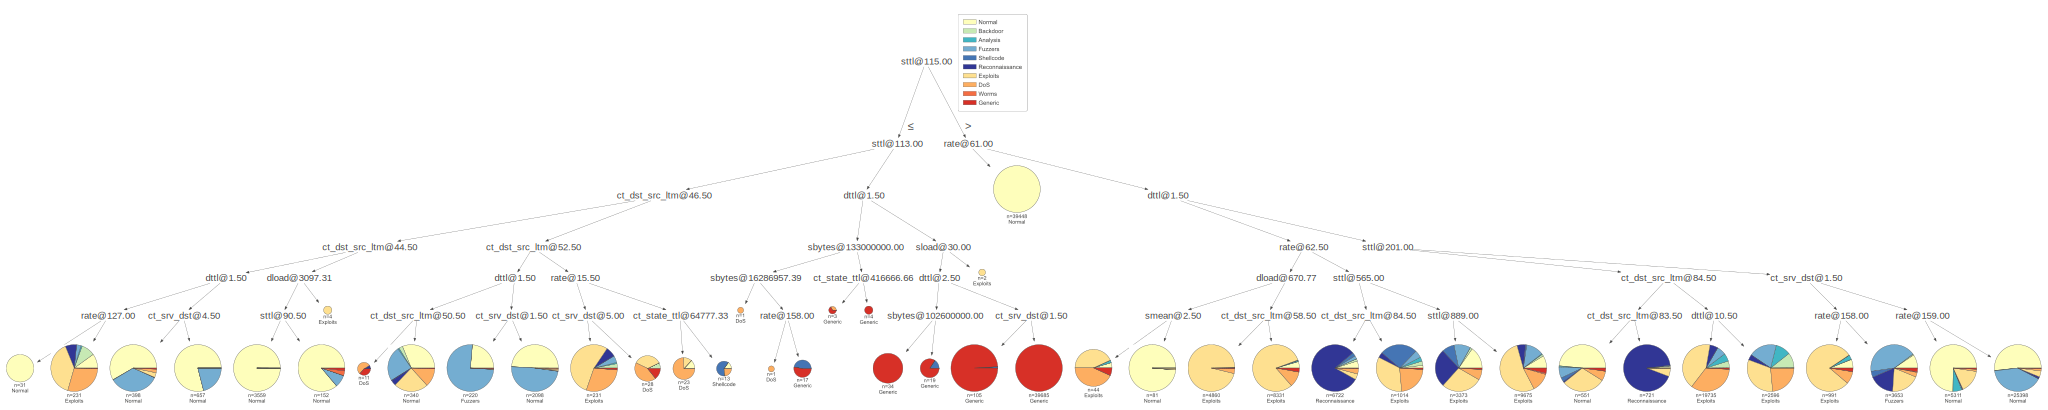

In [42]:

top10= feature_imp.Name[:10].tolist()

attack_names = np.array(df['attack_cat'].unique())

X_top = df.loc[:, df.columns.isin(top10)]
y_top = pd.factorize(df['attack_cat'])[0]


clf_top10 = DecisionTreeClassifier(max_depth=6)

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top, y_top, test_size=0.3, random_state=11)

clf_top10.fit(X_train_top, y_train_top)

viz_model = dtreeviz.model(clf_top10,
                           X_train=X_train_top, y_train=y_train_top, 
                           class_names=attack_names,
                           feature_names=top10)

viz_model.view(fancy=False,scale=1) 

## Random Forest With Attack Category As the Prediction Labels


Accuracy:  0.8234974515536467


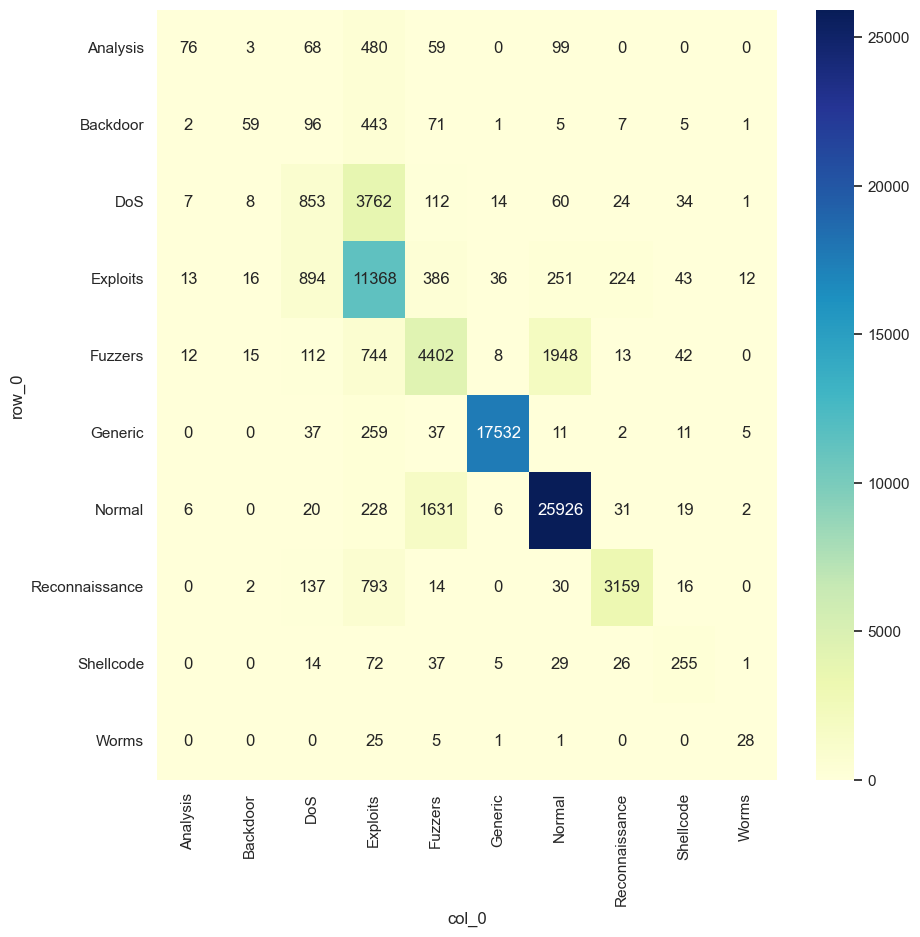

In [43]:
top10= feature_imp.Name[:10].tolist()

X = df.loc[:, df.columns.isin(top10)]

y = df['attack_cat'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

rf = RandomForestClassifier(random_state=11,min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy: ", acc)

cross = pd.crosstab(y_test,  y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cross, annot=True,fmt='d', cmap="YlGnBu")
plt.show()


In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

                precision    recall  f1-score   support

      Analysis       0.66      0.10      0.17       785
      Backdoor       0.57      0.09      0.15       690
           DoS       0.38      0.17      0.24      4875
      Exploits       0.63      0.86      0.72     13243
       Fuzzers       0.65      0.60      0.63      7296
       Generic       1.00      0.98      0.99     17894
        Normal       0.91      0.93      0.92     27869
Reconnaissance       0.91      0.76      0.83      4151
     Shellcode       0.60      0.58      0.59       439
         Worms       0.56      0.47      0.51        60

      accuracy                           0.82     77302
     macro avg       0.69      0.55      0.57     77302
  weighted avg       0.82      0.82      0.81     77302



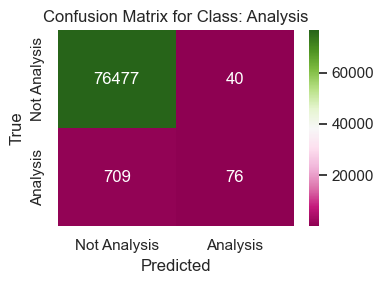

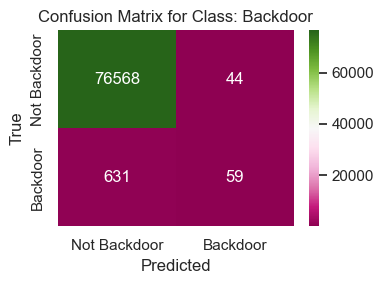

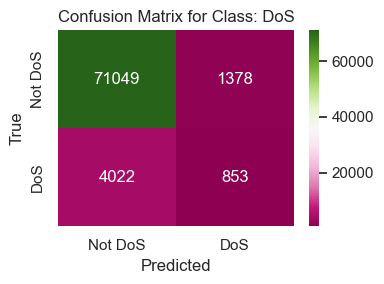

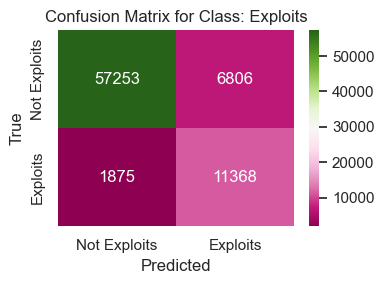

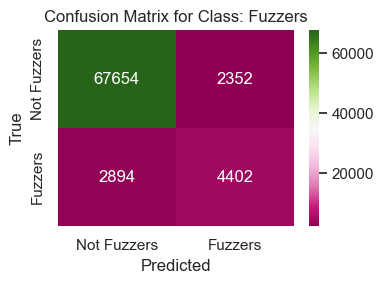

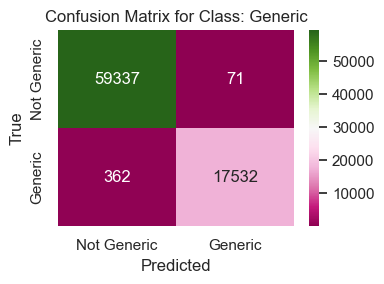

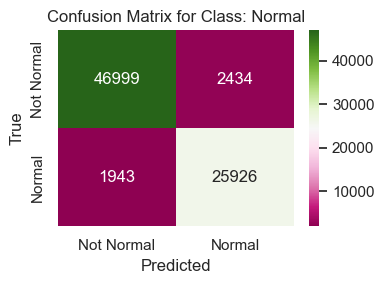

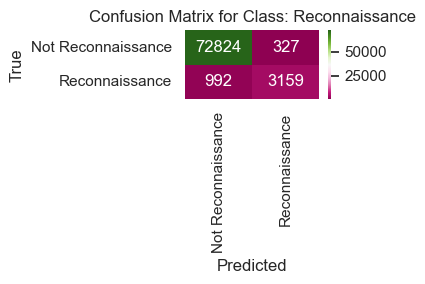

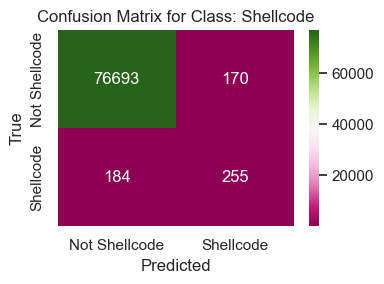

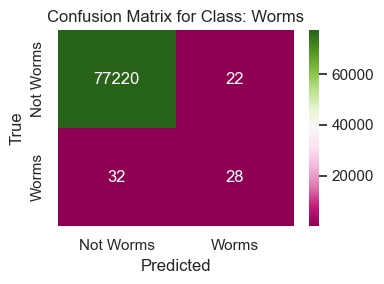

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

# Get unique class labels from y_test
class_names = np.unique(y_test)

# Get multilabel confusion matrices
mcm = multilabel_confusion_matrix(y_test, y_pred, labels=class_names)

# Plot each confusion matrix
for i, class_name in zip(mcm, class_names):
    plt.figure(figsize=(4, 3))
    sns.heatmap(i, annot=True, fmt='d', cmap="PiYG", xticklabels=[f'Not {class_name}', class_name], yticklabels=[f'Not {class_name}', class_name])
    plt.title(f'Confusion Matrix for Class: {class_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


In [46]:
import joblib

# Assuming your model is named 'rf_model'
joblib.dump(rf_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [47]:
import joblib

# Load the trained model
model = joblib.load("random_forest_model.pkl")

# Try accessing feature names
try:
    features = model.feature_names_in_
    print("Feature columns used in training:")
    print(features)
except AttributeError:
    print("⚠️ Feature names are not stored in the model. You need to manually define them.")


Feature columns used in training:
['dur' 'proto' 'service' 'state' 'spkts' 'dpkts' 'sbytes' 'dbytes' 'rate'
 'sttl' 'dttl' 'sload' 'dload' 'sloss' 'dloss' 'sinpkt' 'dinpkt' 'sjit'
 'djit' 'swin' 'stcpb' 'dtcpb' 'dwin' 'tcprtt' 'synack' 'ackdat' 'smean'
 'dmean' 'trans_depth' 'response_body_len' 'ct_srv_src' 'ct_state_ttl'
 'ct_dst_ltm' 'ct_src_dport_ltm' 'ct_dst_sport_ltm' 'ct_dst_src_ltm'
 'is_ftp_login' 'ct_ftp_cmd' 'ct_flw_http_mthd' 'ct_src_ltm' 'ct_srv_dst'
 'is_sm_ips_ports']


In [48]:
import joblib
from sklearn.preprocessing import LabelEncoder

# During preprocessing
proto_le = LabelEncoder()
service_le = LabelEncoder()
state_le = LabelEncoder()

df['proto'] = proto_le.fit_transform(df['proto'])
df['service'] = service_le.fit_transform(df['service'])
df['state'] = state_le.fit_transform(df['state'])

# Save encoders
joblib.dump(proto_le, 'proto_encoder.pkl')
joblib.dump(service_le, 'service_encoder.pkl')
joblib.dump(state_le, 'state_encoder.pkl')

# Save model
joblib.dump(rf_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [49]:
# During training (example):
proto_le = LabelEncoder()
proto_le.fit(df['proto'].astype(str))
joblib.dump(proto_le, 'proto_encoder.pkl')


['proto_encoder.pkl']

In [50]:
print(proto_le.classes_)  # Should list strings like ['icmp', 'tcp', 'udp']


['0' '1' '10' '100' '101' '102' '103' '104' '105' '106' '107' '108' '109'
 '11' '110' '111' '112' '113' '114' '115' '116' '117' '118' '119' '12'
 '120' '121' '122' '123' '124' '125' '126' '127' '128' '129' '13' '130'
 '131' '132' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22' '23' '24'
 '25' '26' '27' '28' '29' '3' '30' '31' '32' '33' '34' '35' '36' '37' '38'
 '39' '4' '40' '41' '42' '43' '44' '45' '46' '47' '48' '49' '5' '50' '51'
 '52' '53' '54' '55' '56' '57' '58' '59' '6' '60' '61' '62' '63' '64' '65'
 '66' '67' '68' '69' '7' '70' '71' '72' '73' '74' '75' '76' '77' '78' '79'
 '8' '80' '81' '82' '83' '84' '85' '86' '87' '88' '89' '9' '90' '91' '92'
 '93' '94' '95' '96' '97' '98' '99']


In [52]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load the full training data (adjust path as needed)
train_df = pd.read_csv(r"C:\Users\91636\Desktop\major_project\New folder\cyber\UNSW_NB15_training-set.csv")  # Use the actual path

# Fit LabelEncoders on full string category lists
proto_le = LabelEncoder()
proto_le.fit(train_df['proto'].astype(str))
joblib.dump(proto_le, 'proto_encoder.pkl')

service_le = LabelEncoder()
service_le.fit(train_df['service'].astype(str))
joblib.dump(service_le, 'service_encoder.pkl')

state_le = LabelEncoder()
state_le.fit(train_df['state'].astype(str))
joblib.dump(state_le, 'state_encoder.pkl')

print("✅ Encoders trained and saved.")


✅ Encoders trained and saved.


In [53]:
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']